In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

In [35]:
df = pd.read_csv('database/flights.csv', low_memory=False)
df['DELAYED'] = np.where(df['ARRIVAL_DELAY'] >= 15,1,0)

In [61]:
cols = df.columns.tolist()
df

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DELAYED
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5819074,2015,12,31,4,B6,688,N657JB,LAX,BOS,2359,...,-26.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
5819075,2015,12,31,4,B6,745,N828JB,JFK,PSE,2359,...,-16.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
5819076,2015,12,31,4,B6,1503,N913JB,JFK,SJU,2359,...,-8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
5819077,2015,12,31,4,B6,333,N527JB,MCO,SJU,2359,...,-10.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0


In [62]:
df = df[df['CANCELLED'] == 0] #removing cancelled flights
df = df[df['DIVERTED'] == 0]  #removing diverted flights

In [68]:
def show_stats(df):
    columns = df.columns.tolist()

    for i in range(len(columns)):
        print('col: ', columns[i], ' nunique: ', df[columns[i]].nunique(), '    total data: ', df[columns[i]].count(), '  nans: ', df[columns[i]].isna().sum())


In [69]:
show_stats(df)

col:  YEAR  nunique:  1     total data:  5714008   nans:  0
col:  MONTH  nunique:  12     total data:  5714008   nans:  0
col:  DAY  nunique:  31     total data:  5714008   nans:  0
col:  DAY_OF_WEEK  nunique:  7     total data:  5714008   nans:  0
col:  AIRLINE  nunique:  14     total data:  5714008   nans:  0
col:  FLIGHT_NUMBER  nunique:  6946     total data:  5714008   nans:  0
col:  TAIL_NUMBER  nunique:  4896     total data:  5714008   nans:  0
col:  ORIGIN_AIRPORT  nunique:  628     total data:  5714008   nans:  0
col:  DESTINATION_AIRPORT  nunique:  629     total data:  5714008   nans:  0
col:  SCHEDULED_DEPARTURE  nunique:  1320     total data:  5714008   nans:  0
col:  DEPARTURE_TIME  nunique:  1440     total data:  5714008   nans:  0
col:  DEPARTURE_DELAY  nunique:  1212     total data:  5714008   nans:  0
col:  TAXI_OUT  nunique:  184     total data:  5714008   nans:  0
col:  WHEELS_OFF  nunique:  1440     total data:  5714008   nans:  0
col:  SCHEDULED_TIME  nunique:  549 

In [138]:
unwanted_cols = [
    'CANCELLED',
    'DIVERTED',
    'CANCELLATION_REASON',
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY',
    'FLIGHT_NUMBER',
    'YEAR'
]

cols_to_keep = [item for item in cols if item not in unwanted_cols]
filtered_df = df[cols_to_keep]

In [139]:
show_stats(filtered_df)

col:  MONTH  nunique:  12     total data:  5714008   nans:  0
col:  DAY  nunique:  31     total data:  5714008   nans:  0
col:  DAY_OF_WEEK  nunique:  7     total data:  5714008   nans:  0
col:  AIRLINE  nunique:  14     total data:  5714008   nans:  0
col:  TAIL_NUMBER  nunique:  4896     total data:  5714008   nans:  0
col:  ORIGIN_AIRPORT  nunique:  628     total data:  5714008   nans:  0
col:  DESTINATION_AIRPORT  nunique:  629     total data:  5714008   nans:  0
col:  SCHEDULED_DEPARTURE  nunique:  1320     total data:  5714008   nans:  0
col:  DEPARTURE_TIME  nunique:  1440     total data:  5714008   nans:  0
col:  DEPARTURE_DELAY  nunique:  1212     total data:  5714008   nans:  0
col:  TAXI_OUT  nunique:  184     total data:  5714008   nans:  0
col:  WHEELS_OFF  nunique:  1440     total data:  5714008   nans:  0
col:  SCHEDULED_TIME  nunique:  549     total data:  5714008   nans:  0
col:  ELAPSED_TIME  nunique:  712     total data:  5714008   nans:  0
col:  AIR_TIME  nunique:  

In [140]:
filtered_df_sample = filtered_df.sample(frac=0.02, random_state=42)
df_sample = df.sample(frac=0.02, random_state=42)
show_stats(df_sample)

col:  YEAR  nunique:  1     total data:  114280   nans:  0
col:  MONTH  nunique:  12     total data:  114280   nans:  0
col:  DAY  nunique:  31     total data:  114280   nans:  0
col:  DAY_OF_WEEK  nunique:  7     total data:  114280   nans:  0
col:  AIRLINE  nunique:  14     total data:  114280   nans:  0
col:  FLIGHT_NUMBER  nunique:  6383     total data:  114280   nans:  0
col:  TAIL_NUMBER  nunique:  4645     total data:  114280   nans:  0
col:  ORIGIN_AIRPORT  nunique:  586     total data:  114280   nans:  0
col:  DESTINATION_AIRPORT  nunique:  588     total data:  114280   nans:  0
col:  SCHEDULED_DEPARTURE  nunique:  1234     total data:  114280   nans:  0
col:  DEPARTURE_TIME  nunique:  1335     total data:  114280   nans:  0
col:  DEPARTURE_DELAY  nunique:  484     total data:  114280   nans:  0
col:  TAXI_OUT  nunique:  139     total data:  114280   nans:  0
col:  WHEELS_OFF  nunique:  1336     total data:  114280   nans:  0
col:  SCHEDULED_TIME  nunique:  471     total data:

In [141]:
def compare(df, col1, col2):

    def_graph = df.groupby(col1)[col2].mean().reset_index()

    # 2. Plotar
    plt.bar(def_graph[col1], def_graph[col2], color='skyblue')

    # Customização
    plt.title(f'{col2} x {col1}')
    plt.xlabel(col1)
    plt.ylabel(f'{col2} mean')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()

In [142]:
filtered_df_sample['MONTH'].value_counts()

MONTH
7     10286
8     10157
3      9916
5      9812
6      9730
10     9616
12     9494
4      9458
9      9264
1      9252
11     9192
2      8103
Name: count, dtype: int64

In [143]:
filtered_df_sample[filtered_df_sample['DELAYED'] == 1]['MONTH'].value_counts().sort_index()

MONTH
1     1906
2     1863
3     1876
4     1640
5     1771
6     2267
7     2198
8     1861
9     1212
10    1166
11    1418
12    1965
Name: count, dtype: int64

In [144]:
show_stats(filtered_df_sample)

col:  MONTH  nunique:  12     total data:  114280   nans:  0
col:  DAY  nunique:  31     total data:  114280   nans:  0
col:  DAY_OF_WEEK  nunique:  7     total data:  114280   nans:  0
col:  AIRLINE  nunique:  14     total data:  114280   nans:  0
col:  TAIL_NUMBER  nunique:  4645     total data:  114280   nans:  0
col:  ORIGIN_AIRPORT  nunique:  586     total data:  114280   nans:  0
col:  DESTINATION_AIRPORT  nunique:  588     total data:  114280   nans:  0
col:  SCHEDULED_DEPARTURE  nunique:  1234     total data:  114280   nans:  0
col:  DEPARTURE_TIME  nunique:  1335     total data:  114280   nans:  0
col:  DEPARTURE_DELAY  nunique:  484     total data:  114280   nans:  0
col:  TAXI_OUT  nunique:  139     total data:  114280   nans:  0
col:  WHEELS_OFF  nunique:  1336     total data:  114280   nans:  0
col:  SCHEDULED_TIME  nunique:  471     total data:  114280   nans:  0
col:  ELAPSED_TIME  nunique:  523     total data:  114280   nans:  0
col:  AIR_TIME  nunique:  489     total d

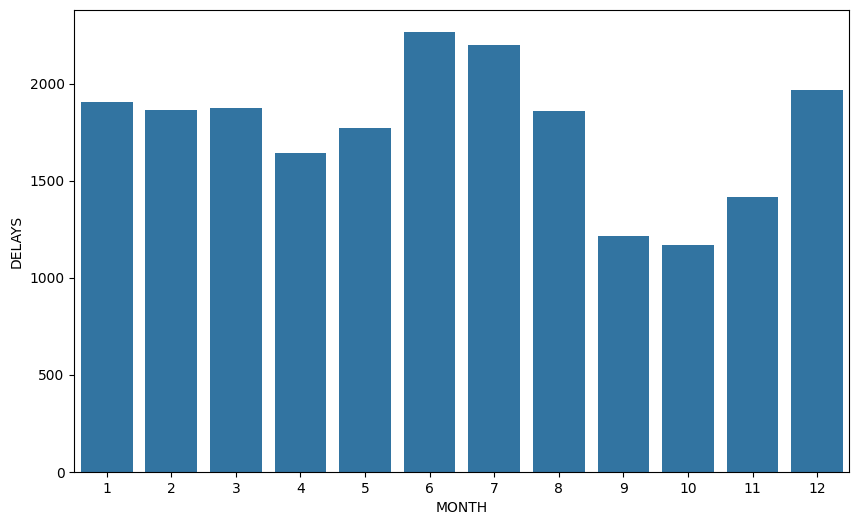

In [158]:
df_somente_atrasos = filtered_df_sample[filtered_df_sample['DELAYED'] == 1]
x='MONTH'

plt.figure(figsize=(10, 6))
sns.countplot(data=df_somente_atrasos, x=x)

plt.xlabel(x)
plt.ylabel('DELAYS')
plt.show()